<a href="https://www.kaggle.com/code/lalit7881/classroom-air-quality-eda?scriptVersionId=316003114" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/uniquetech/classroom-air-quality/unique_tech_classroom_air_quality.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/uniquetech/classroom-air-quality/unique_tech_classroom_air_quality.csv")

In [3]:
df.head()

,timestamp,school_period,student_count_estimated,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,robot_x_pos,robot_y_pos,ventilation_decision,air_quality_label
0,2025-11-12 08:00:00,Morning Entry,11,442.1,5.16,21.0,45.0,2.0,4.0,IDLE,Good
1,2025-11-12 08:01:42,Morning Entry,6,444.6,5.08,21.0,44.8,2.2,4.0,IDLE,Good
2,2025-11-12 08:03:24,Morning Entry,11,466.9,5.93,21.0,44.7,2.7,3.8,IDLE,Good
3,2025-11-12 08:05:06,Morning Entry,6,483.6,5.49,21.0,44.6,2.7,3.8,IDLE,Good
4,2025-11-12 08:06:48,Morning Entry,16,520.6,6.25,21.0,44.7,3.2,3.9,IDLE,Good


In [4]:
df.tail()

,timestamp,school_period,student_count_estimated,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,robot_x_pos,robot_y_pos,ventilation_decision,air_quality_label
495,2025-11-12 22:01:30,End of Day,4,501.6,6.26,20.2,41.8,0.0,0.0,IDLE,Good
496,2025-11-12 22:03:12,End of Day,1,474.9,6.66,20.2,41.6,0.2,0.0,IDLE,Good
497,2025-11-12 22:04:54,End of Day,0,454.7,6.26,20.2,41.5,0.5,0.1,IDLE,Good
498,2025-11-12 22:06:36,End of Day,6,471.8,6.13,20.2,41.5,0.7,0.0,IDLE,Good
499,2025-11-12 22:08:18,End of Day,9,488.6,5.85,20.2,41.6,1.1,0.0,IDLE,Good


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                500 non-null    object 
 1   school_period            500 non-null    object 
 2   student_count_estimated  500 non-null    int64  
 3   co2_ppm                  500 non-null    float64
 4   pm25_ugm3                500 non-null    float64
 5   temperature_c            500 non-null    float64
 6   humidity_pct             500 non-null    float64
 7   robot_x_pos              500 non-null    float64
 8   robot_y_pos              500 non-null    float64
 9   ventilation_decision     500 non-null    object 
 10  air_quality_label        500 non-null    object 
dtypes: float64(6), int64(1), object(4)
memory usage: 43.1+ KB


In [6]:
df.describe()

,student_count_estimated,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,robot_x_pos,robot_y_pos
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,11.184000,619.266400,8.439960,20.48980,44.594400,2.005800,1.990000
std,9.446301,155.967082,2.718404,0.19191,3.057506,1.415639,1.420781
min,0.000000,432.200000,4.400000,20.20000,41.300000,0.000000,0.000000
25%,3.000000,493.825000,6.170000,20.40000,41.800000,0.600000,0.600000
50%,7.000000,529.200000,7.080000,20.50000,42.800000,2.050000,2.000000
75%,22.000000,801.425000,11.512500,20.50000,47.800000,3.400000,3.400000
max,27.000000,893.000000,14.500000,21.00000,49.700000,4.000000,4.000000


In [7]:
df.isnull().sum()

timestamp                  0
school_period              0
student_count_estimated    0
co2_ppm                    0
pm25_ugm3                  0
temperature_c              0
humidity_pct               0
robot_x_pos                0
robot_y_pos                0
ventilation_decision       0
air_quality_label          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['timestamp', 'school_period', 'student_count_estimated', 'co2_ppm',
       'pm25_ugm3', 'temperature_c', 'humidity_pct', 'robot_x_pos',
       'robot_y_pos', 'ventilation_decision', 'air_quality_label'],
      dtype='object')

In [10]:
df.dtypes

timestamp                   object
school_period               object
student_count_estimated      int64
co2_ppm                    float64
pm25_ugm3                  float64
temperature_c              float64
humidity_pct               float64
robot_x_pos                float64
robot_y_pos                float64
ventilation_decision        object
air_quality_label           object
dtype: object

In [11]:
df.shape

(500, 11)

In [12]:
df.nunique()

timestamp                  500
school_period                9
student_count_estimated     25
co2_ppm                    449
pm25_ugm3                  338
temperature_c                9
humidity_pct                75
robot_x_pos                 41
robot_y_pos                 41
ventilation_decision         2
air_quality_label            2
dtype: int64

## EDA

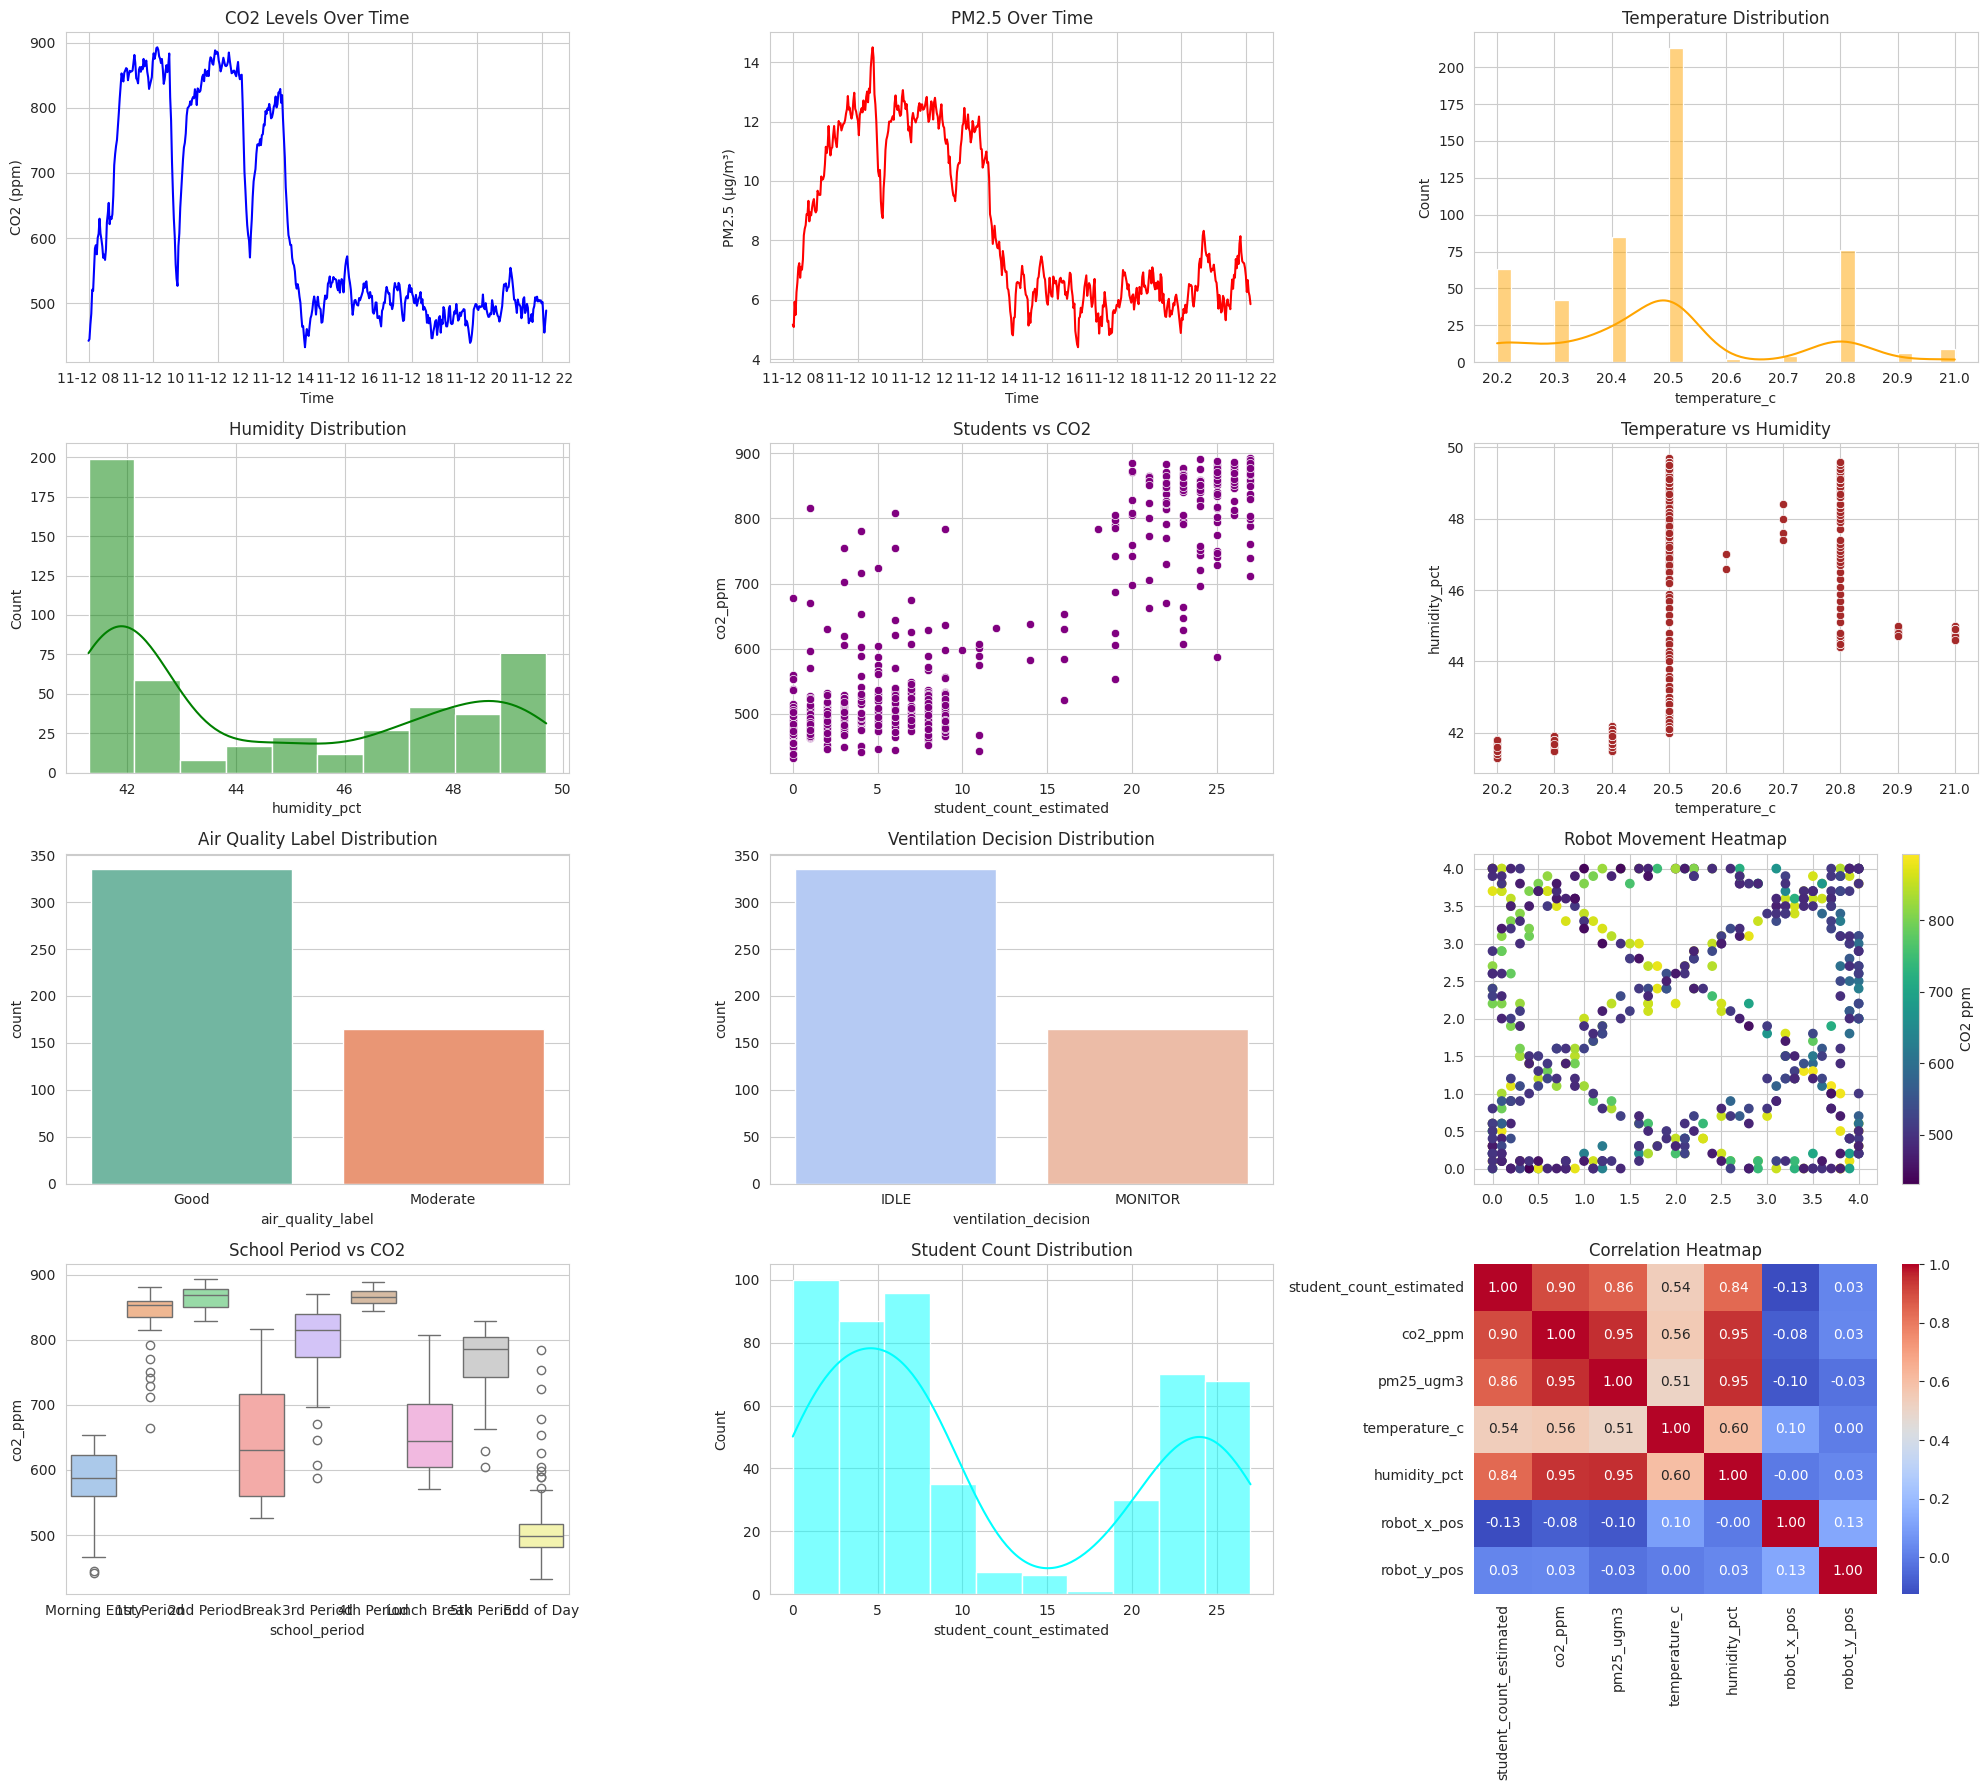

In [13]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# ===============================
# SET STYLE
# ===============================
sns.set_style("whitegrid")

# ===============================
# CREATE FIGURE
# ===============================
plt.figure(figsize=(20, 18))

# ===============================
# 1. CO2 OVER TIME
# ===============================
plt.subplot(4, 3, 1)
plt.plot(df['timestamp'], df['co2_ppm'], color='blue')
plt.title('CO2 Levels Over Time')
plt.xlabel('Time')
plt.ylabel('CO2 (ppm)')

# ===============================
# 2. PM2.5 OVER TIME
# ===============================
plt.subplot(4, 3, 2)
plt.plot(df['timestamp'], df['pm25_ugm3'], color='red')
plt.title('PM2.5 Over Time')
plt.xlabel('Time')
plt.ylabel('PM2.5 (µg/m³)')

# ===============================
# 3. TEMPERATURE DISTRIBUTION
# ===============================
plt.subplot(4, 3, 3)
sns.histplot(df['temperature_c'], kde=True, color='orange')
plt.title('Temperature Distribution')

# ===============================
# 4. HUMIDITY DISTRIBUTION
# ===============================
plt.subplot(4, 3, 4)
sns.histplot(df['humidity_pct'], kde=True, color='green')
plt.title('Humidity Distribution')

# ===============================
# 5. STUDENT COUNT VS CO2
# ===============================
plt.subplot(4, 3, 5)
sns.scatterplot(
    x=df['student_count_estimated'],
    y=df['co2_ppm'],
    color='purple'
)
plt.title('Students vs CO2')

# ===============================
# 6. TEMPERATURE VS HUMIDITY
# ===============================
plt.subplot(4, 3, 6)
sns.scatterplot(
    x=df['temperature_c'],
    y=df['humidity_pct'],
    color='brown'
)
plt.title('Temperature vs Humidity')

# ===============================
# 7. AIR QUALITY LABEL COUNT
# ===============================
plt.subplot(4, 3, 7)
sns.countplot(
    x='air_quality_label',
    data=df,
    palette='Set2'
)
plt.title('Air Quality Label Distribution')

# ===============================
# 8. VENTILATION DECISION COUNT
# ===============================
plt.subplot(4, 3, 8)
sns.countplot(
    x='ventilation_decision',
    data=df,
    palette='coolwarm'
)
plt.title('Ventilation Decision Distribution')

# ===============================
# 9. ROBOT POSITION HEATMAP
# ===============================
plt.subplot(4, 3, 9)
plt.scatter(
    df['robot_x_pos'],
    df['robot_y_pos'],
    c=df['co2_ppm'],
    cmap='viridis'
)
plt.colorbar(label='CO2 ppm')
plt.title('Robot Movement Heatmap')

# ===============================
# 10. SCHOOL PERIOD VS CO2
# ===============================
plt.subplot(4, 3, 10)
sns.boxplot(
    x='school_period',
    y='co2_ppm',
    data=df,
    palette='pastel'
)
plt.title('School Period vs CO2')

# ===============================
# 11. STUDENT COUNT DISTRIBUTION
# ===============================
plt.subplot(4, 3, 11)
sns.histplot(df['student_count_estimated'], color='cyan', kde=True)
plt.title('Student Count Distribution')

# ===============================
# 12. CORRELATION HEATMAP
# ===============================
plt.subplot(4, 3, 12)
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')

# ===============================
# FINAL LAYOUT
# ===============================
plt.tight_layout()
plt.show()

## Feature engineering


Logistic Regression
Accuracy: 1.0
AUC: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        67
           1       1.00      1.00      1.00        33

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100


Random Forest
Accuracy: 1.0
AUC: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        67
           1       1.00      1.00      1.00        33

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100


Gradient Boosting
Accuracy: 1.0
AUC: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        67
           1       1.00      1.00     

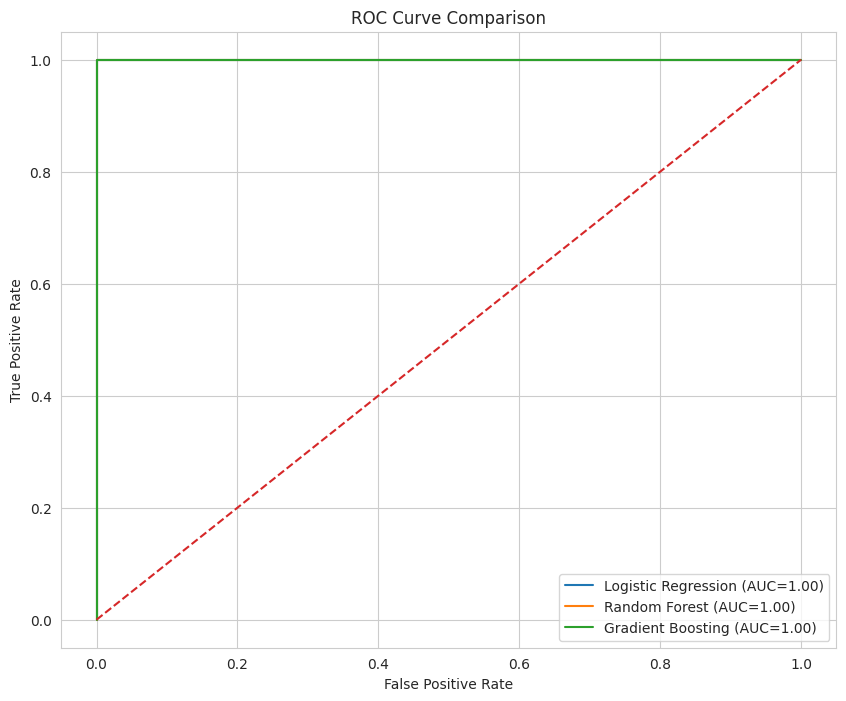

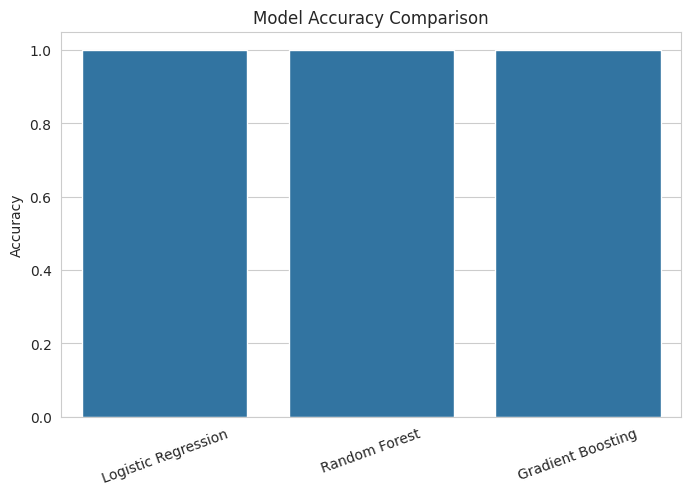

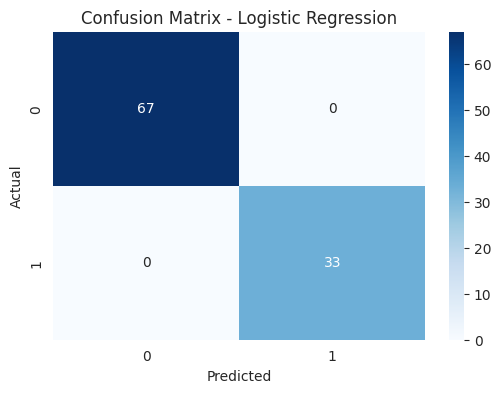

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


# =========================================
# 3. FEATURE ENGINEERING (NO LEAKAGE)
# =========================================
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek

df.drop(columns=['timestamp'], inplace=True)

# =========================================
# 4. DEFINE TARGET
# =========================================
target_col = 'air_quality_label'

X = df.drop(columns=[target_col])
y = df[target_col]

# =========================================
# 5. TRAIN TEST SPLIT (NO LEAKAGE)
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Avoid copy warning
X_train = X_train.copy()
X_test = X_test.copy()

# =========================================
# 6. LABEL ENCODING (ONLY TRAIN)
# =========================================
# Target encoding
le_target = LabelEncoder()
y_train = le_target.fit_transform(y_train)
y_test = le_target.transform(y_test)

# Feature encoding
cat_cols = X.select_dtypes(include='object').columns

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    encoders[col] = le

# =========================================
# 7. SCALING
# =========================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================================
# 8. MODELS
# =========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier()
}

# =========================================
# 9. TRAIN + EVALUATE
# =========================================
results = {}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    
    # Train
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # ✅ Correct probability (binary classification)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    
    # ✅ Correct AUC
    auc_score = roc_auc_score(y_test, y_prob)
    
    results[name] = acc
    
    print("\n==============================")
    print(name)
    print("==============================")
    print("Accuracy:", acc)
    print("AUC:", auc_score)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.2f})")

# ROC Plot
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# =========================================
# 10. ACCURACY COMPARISON
# =========================================
plt.figure(figsize=(8, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

# =========================================
# 11. CONFUSION MATRIX (BEST MODEL)
# =========================================
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

from sklearn.metrics import confusion_matrix

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Thank you... pls upvote!!!!!!!